# Healthcare Appointment No-Show Analytics

## Business Context

Missed medical appointments are an operational challenge for public healthcare systems because an unattended appointment may represent unused clinical capacity while other patients remain on waiting lists.

Recent Brazilian examples have highlighted the relevance of appointment absenteeism and the use of communication and scheduling strategies to reduce missed consultations.

This project uses appointment-level data from Brazil to investigate where appointment capacity is being lost and which operational or contextual characteristics are associated with no-show behaviour.

### Main Business Question

> **How can a public healthcare network use scheduling data to identify absenteeism patterns and support strategies that reduce lost appointment capacity and waiting-list pressure?**

### Analytical Questions

The project is structured around six operational questions:

1. Which neighbourhoods concentrate the highest appointment absenteeism?
2. What is the impact of the time between scheduling and the appointment?
3. Which days present higher no-show risk?
4. Is SMS communication associated with better attendance?
5. How many appointment slots could potentially be recovered under different reduction scenarios?
6. Which groups could be prioritized for communication or scheduling interventions?

The current notebook section focuses on **Question 1: neighbourhood-level appointment losses and socioeconomic context**.


## 1. Libraries

Only libraries required for the current analytical workflow are imported. Machine-learning libraries are intentionally excluded at this stage because the project is focused on descriptive analytics, data quality, integration, modelling and business intelligence.


In [1]:
import io
import re
import zipfile
import unicodedata
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize


## 2. Data Loading

The primary dataset is the **Medical Appointment No Shows** dataset, containing appointment records from Brazil.

Each row represents one scheduled medical appointment and includes patient characteristics, scheduling dates, neighbourhood, SMS information and attendance outcome.


In [2]:
df = pd.read_csv('Healthcare_no_shows.csv')


## 3. Initial Data Profiling

The first step is to understand the structure, distributions and potential quality issues in the raw dataset before creating analytical variables or applying transformations.


In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
df.describe(include= 'O')

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_9816\2003251587.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include= 'O')


,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [7]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

### Privacy Note

The dataset does not contain direct identifiers such as patient names, email addresses or phone numbers. It does contain numeric patient and appointment identifiers, which are used only for analytical purposes in this project.

No attempt is made to identify individual patients.


### Date Conversion and Lead-Time Feature

`ScheduledDay` and `AppointmentDay` are converted to datetime values.

A new variable, `waiting_days`, measures the number of **calendar days** between scheduling and the appointment.

The timestamps require special treatment because `ScheduledDay` contains a time component while `AppointmentDay` is recorded at midnight. Direct subtraction would incorrectly classify many same-day appointments as having a negative waiting time.

For this reason, both timestamps are normalized to their calendar date before calculating the interval:

`waiting_days = appointment date - scheduling date`


In [8]:
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

# Use calendar dates rather than timestamps.
# Without normalization, same-day appointments can appear as -1 day because
# ScheduledDay contains a time while AppointmentDay is recorded at midnight.
df['waiting_days'] = (
    df['AppointmentDay'].dt.normalize()
    - df['ScheduledDay'].dt.normalize()
).dt.days


## 4. Data Quality Assessment

The analysis checks whether the variables required for later business questions comply with basic logical and integrity rules.

### Applied Rules

**DQ-001 — Appointment ID Uniqueness**  
`AppointmentID` should uniquely identify an appointment.

**DQ-002 — Patient ID Completeness**  
`PatientId` should not be null.

**DQ-003 — Valid Age**  
`Age >= 0`

**DQ-004 — Scheduling Consistency**  
`AppointmentDay >= ScheduledDay`

**DQ-005 — Valid Attendance Status**  
`No-show` should contain only the expected domain values.


In [9]:
print("Duplicated Appointment IDs:",
      df['AppointmentID'].duplicated().sum())

print("Null Patient IDs:",
      df['PatientId'].isna().sum())

print("Negative ages:",
      (df['Age'] < 0).sum())

print("Negative waiting days:",
      (df['waiting_days'] < 0).sum())

print("\nNo-show domain:")
print(df['No-show'].value_counts(dropna=False))


Duplicated Appointment IDs: 0
Null Patient IDs: 0
Negative ages: 1
Negative waiting days: 5

No-show domain:
No-show
No     88208
Yes    22319
Name: count, dtype: int64


### Data Quality Treatment — Invalid Records

The data quality assessment identified a very small number of logically invalid records:

- 5 appointments had `waiting_days < 0`, meaning the appointment date occurred before the scheduling date.
- 1 record had `Age < 0`, which is not a valid patient age.

Together, these records represent approximately **0.005%** of the dataset.

Because they violate basic temporal or demographic validity rules and may distort analyses involving age or scheduling lead time, they are excluded from the analytical dataset.

The raw dataset remains unchanged. All exclusions are applied only to the cleaned analytical dataset.


In [10]:
records_before = len(df)

invalid_age = df['Age'] < 0
invalid_waiting_days = df['waiting_days'] < 0

df_clean = df[
    (~invalid_age) &
    (~invalid_waiting_days)
].copy()

records_after = len(df_clean)
records_removed = records_before - records_after
removal_rate = (records_removed / records_before) * 100

print(f"Records before cleaning: {records_before:,}")
print(f"Records after cleaning:  {records_after:,}")
print(f"Records removed:         {records_removed:,}")
print(f"Removal rate:            {removal_rate:.4f}%")


Records before cleaning: 110,527
Records after cleaning:  110,521
Records removed:         6
Removal rate:            0.0054%


### Attendance Flag

The original `No-show` field is converted into a binary analytical variable:

- `0` = patient attended the appointment
- `1` = patient missed the appointment

This simplifies aggregation and KPI calculation.


In [11]:
df_clean['no_show_flag'] = df_clean['No-show'].map({
    'No': 0,
    'Yes': 1
})


## 5. External Data Enrichment — Neighbourhood Income

To investigate whether appointment absenteeism varies across different socioeconomic contexts, the healthcare dataset is enriched with neighbourhood-level income data from the **2022 Brazilian Census (IBGE)**.

The integration key is the neighbourhood:

`Medical Appointment.Neighbourhood` → `IBGE.NM_BAIRRO`

### Analytical Limitation

The income indicators describe the socioeconomic context of the neighbourhood and **do not represent the individual income of each patient**.

Therefore, this analysis can identify area-level associations between neighbourhood income and no-show patterns, but it cannot conclude that individual low-income patients are more likely to miss appointments.


### 5.1 Download IBGE Neighbourhood Income Data


In [12]:
url_ibge = (
    "https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/"
    "Agregados_por_Setores_Censitarios_Rendimento_do_Responsavel/"
    "Agregados_por_bairros_renda_responsavel_BR_20260508_csv.zip"
)

response = requests.get(url_ibge)
response.raise_for_status()

zip_ibge = zipfile.ZipFile(io.BytesIO(response.content))

csv_files = [
    file for file in zip_ibge.namelist()
    if file.lower().endswith('.csv')
]

ibge = pd.read_csv(
    zip_ibge.open(csv_files[0]),
    sep=';',
    encoding='latin1',
    low_memory=False
)

print("IBGE dataset shape:", ibge.shape)
print("Columns:", ibge.columns.tolist())


IBGE dataset shape: (17378, 8)
Columns: ['CD_BAIRRO', 'NM_BAIRRO', 'V06001', 'V06002', 'V06003', 'V06004', 'V06005', 'V06006']


### 5.2 Filter Vitória, Espírito Santo

The IBGE neighbourhood code for Vitória uses the municipal prefix `3205309`. The national neighbourhood dataset is therefore restricted to Vitória before integration.


In [13]:
ibge_vitoria = ibge[
    ibge['CD_BAIRRO']
    .astype(str)
    .str.startswith('3205309')
].copy()

print("Vitória neighbourhood records:", len(ibge_vitoria))


Vitória neighbourhood records: 78


### 5.3 IBGE Income Variables

The variables were interpreted using the official IBGE data dictionary for household reference-person income.

For this project, the main socioeconomic indicators are:

- `V06004` — nominal average monthly income of household reference persons with income;
- `V06006` — nominal median monthly income of household reference persons with income.

The **median income** is used as the primary indicator because it is less sensitive to extreme values than the mean.

These variables refer to the income of the household reference person and should not be interpreted as individual patient income.


In [14]:
ibge_vitoria = ibge_vitoria.rename(columns={
    'V06001': 'responsible_persons',
    'V06002': 'residents',
    'V06003': 'residents_variance',
    'V06004': 'income_mean',
    'V06005': 'income_variance',
    'V06006': 'income_median'
})

income_neighbourhood = ibge_vitoria[
    [
        'CD_BAIRRO',
        'NM_BAIRRO',
        'responsible_persons',
        'residents',
        'income_mean',
        'income_median'
    ]
].copy()


### 5.4 Standardize Neighbourhood Names

Neighbourhood names from independent sources may differ because of capitalization, accents, apostrophes, punctuation or extra spaces.

A standardized matching key is therefore created before integration.

The final normalization rule was improved after identifying a mismatch between `JOANA D´ARC` in the healthcare dataset and `Joana D'arc` in the IBGE data.


In [15]:
def normalize_neighbourhood(value):
    if pd.isna(value):
        return value

    value = str(value).strip().upper()

    # Remove apostrophes and similar characters before Unicode normalization
    value = re.sub(r"[´'`’]", "", value)

    # Remove accents
    value = ''.join(
        char for char in unicodedata.normalize('NFKD', value)
        if not unicodedata.combining(char)
    )

    # Remove remaining punctuation
    value = re.sub(r"[^\w\s]", "", value)

    # Normalize repeated spaces
    value = re.sub(r"\s+", " ", value).strip()

    return value


df_clean['neighbourhood_key'] = (
    df_clean['Neighbourhood']
    .apply(normalize_neighbourhood)
)

income_neighbourhood['neighbourhood_key'] = (
    income_neighbourhood['NM_BAIRRO']
    .apply(normalize_neighbourhood)
)


### 5.5 Validate Matching Quality

Before merging the datasets, the neighbourhood dimension is checked for duplicate keys and the matching coverage is measured both by:

- number of unique neighbourhoods;
- number of appointment records covered.

This avoids performing a silent merge without understanding its quality.


In [16]:
duplicate_keys = (
    income_neighbourhood['neighbourhood_key']
    .duplicated()
    .sum()
)

medical_neighbourhoods = set(
    df_clean['neighbourhood_key']
    .dropna()
    .unique()
)

ibge_neighbourhoods = set(
    income_neighbourhood['neighbourhood_key']
    .dropna()
    .unique()
)

matched = medical_neighbourhoods & ibge_neighbourhoods
unmatched = medical_neighbourhoods - ibge_neighbourhoods

coverage = (
    df_clean['neighbourhood_key']
    .isin(ibge_neighbourhoods)
    .mean() * 100
)

print("Duplicate IBGE neighbourhood keys:", duplicate_keys)
print("Medical neighbourhoods:", len(medical_neighbourhoods))
print("Matched neighbourhoods:", len(matched))
print("Unmatched neighbourhoods:", len(unmatched))
print("Unmatched:", sorted(unmatched))
print(f"Appointment-record coverage: {coverage:.4f}%")


Duplicate IBGE neighbourhood keys: 0
Medical neighbourhoods: 81
Matched neighbourhoods: 78
Unmatched neighbourhoods: 3
Unmatched: ['AEROPORTO', 'ILHAS OCEANICAS DE TRINDADE', 'PARQUE INDUSTRIAL']
Appointment-record coverage: 99.9900%


### Final Neighbourhood Matching Result

After standardizing capitalization, accents, apostrophes, punctuation and spacing:

- **78 of 80 neighbourhoods** were matched to the IBGE socioeconomic dataset.
- The only unmatched locations were:
  - `AEROPORTO`
  - `ILHAS OCEANICAS DE TRINDADE`
- These two locations account for only **7 appointment records**.

The unmatched records are retained in the healthcare dataset, but their neighbourhood-level income variables remain null.

No income values are imputed, preserving the integrity of the external socioeconomic information.


## 6. Neighbourhood Analysis

The neighbourhood analysis addresses the first business question:

> **Where are appointment slots being lost, and is neighbourhood socioeconomic context associated with no-show behaviour?**

Three complementary perspectives are used:

1. **Absolute no-shows** — where the largest number of appointment slots is lost.
2. **No-show rate** — where absenteeism represents a larger share of scheduled appointments.
3. **Socioeconomic context** — whether neighbourhood income is associated with different no-show patterns.


### 6.1 Merge Healthcare and IBGE Data

The relationship is expected to be **many appointments to one neighbourhood**. The merge therefore uses `validate='many_to_one'` to prevent accidental record multiplication.


In [17]:
df_enriched = df_clean.merge(
    income_neighbourhood[
        [
            'neighbourhood_key',
            'income_mean',
            'income_median',
            'responsible_persons',
            'residents'
        ]
    ],
    on='neighbourhood_key',
    how='left',
    validate='many_to_one'
)

print("Before merge:", len(df_clean))
print("After merge: ", len(df_enriched))


Before merge: 110521
After merge:  110521


### 6.2 Build the Neighbourhood Analytical Table


In [18]:
neighbourhood_analysis = (
    df_enriched.groupby('Neighbourhood')
    .agg(
        appointments=('AppointmentID', 'count'),
        no_shows=('no_show_flag', 'sum'),
        no_show_rate=('no_show_flag', 'mean'),
        income_mean=('income_mean', 'first'),
        income_median=('income_median', 'first')
    )
    .reset_index()
)

neighbourhood_analysis['no_show_rate'] *= 100

neighbourhood_analysis.head()


,Neighbourhood,appointments,no_shows,no_show_rate,income_mean,income_median
0,AEROPORTO,8,1,12.500000,NaN,NaN
1,ANDORINHAS,2262,521,23.032714,"2240,08",1500.0
2,ANTÔNIO HONÓRIO,271,50,18.450185,"4399,63",3100.0
3,ARIOVALDO FAVALESSA,282,62,21.985816,"2346,41",1850.0
4,BARRO VERMELHO,423,91,21.513002,"14873,97",10001.0


### 6.3 Where Are the Largest Numbers of Appointment Slots Being Lost?

Absolute no-shows identify neighbourhoods with the greatest operational volume of missed appointments.

This metric should not be interpreted as risk by itself: a neighbourhood may have many no-shows simply because it also has a very large number of scheduled appointments.


In [19]:
top_no_shows = (
    neighbourhood_analysis
    .sort_values('no_shows', ascending=False)
    .head(15)
)

top_no_shows


,Neighbourhood,appointments,no_shows,no_show_rate,income_mean,income_median
38,JARDIM CAMBURI,7717,1465,18.984061,"7597,89",5500.0
43,MARIA ORTIZ,5805,1219,20.999139,"2377,33",1800.0
36,ITARARÉ,3514,923,26.266363,"2264,80",1500.0
59,RESISTÊNCIA,4430,905,20.428894,"1709,00",1300.0
10,CENTRO,3334,703,21.085783,"4390,34",3001.0
40,JESUS DE NAZARETH,2853,696,24.395373,"1718,29",1300.0
39,JARDIM DA PENHA,3877,631,16.275471,"7832,03",6000.0
9,CARATOÍRA,2565,591,23.040936,"2116,63",1700.0
78,TABUAZEIRO,3131,572,18.268924,"2920,43",2000.0
8,BONFIM,2773,550,19.834115,"1976,15",1212.0


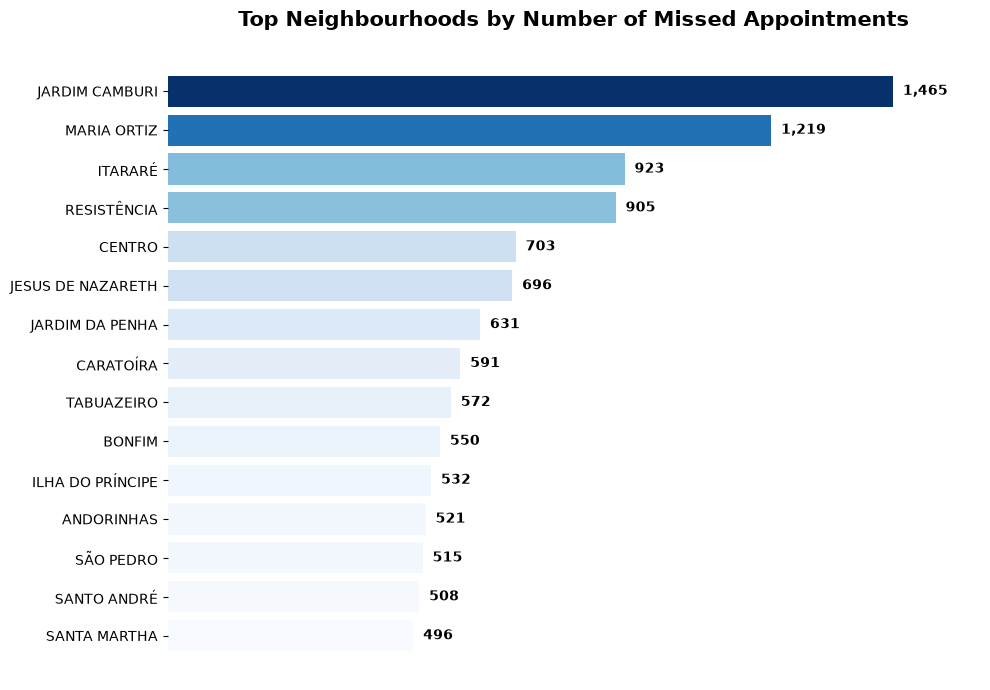

In [20]:
plot_data = top_no_shows.sort_values(
    'no_shows',
    ascending=True
)

norm = Normalize(
    vmin=plot_data['no_shows'].min(),
    vmax=plot_data['no_shows'].max()
)

colors = cm.Blues(
    norm(plot_data['no_shows'])
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_data['Neighbourhood'],
    plot_data['no_shows'],
    color=colors
)

for bar, value in zip(bars, plot_data['no_shows']):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Top Neighbourhoods by Number of Missed Appointments',
    fontsize=15,
    fontweight='bold',
    pad=15
)

# Values are shown directly on the bars, so the numeric axis is redundant.
ax.xaxis.set_visible(False)
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(
    0,
    plot_data['no_shows'].max() * 1.12
)

plt.tight_layout()
plt.show()


### 6.4 Which Neighbourhoods Have the Highest No-Show Rates?

A minimum volume threshold of **100 appointments** is used to avoid overemphasizing unstable rates from neighbourhoods with very small denominators.


In [21]:
high_rate_neighbourhoods = (
    neighbourhood_analysis[
        neighbourhood_analysis['appointments'] >= 100
    ]
    .sort_values('no_show_rate', ascending=False)
    .head(15)
)

high_rate_neighbourhoods


,Neighbourhood,appointments,no_shows,no_show_rate,income_mean,income_median
70,SANTOS DUMONT,1276,369,28.918495,"1993,44",1300.0
61,SANTA CECÍLIA,448,123,27.455357,"6773,21",4500.0
62,SANTA CLARA,506,134,26.482213,"3391,99",2400.0
36,ITARARÉ,3514,923,26.266363,"2264,80",1500.0
40,JESUS DE NAZARETH,2853,696,24.395373,"1718,29",1300.0
28,HORTO,175,42,24.000000,"3467,67",2500.0
33,ILHA DO PRÍNCIPE,2266,532,23.477493,"1856,88",1212.0
9,CARATOÍRA,2565,591,23.040936,"2116,63",1700.0
1,ANDORINHAS,2262,521,23.032714,"2240,08",1500.0
56,PRAIA DO SUÁ,1288,294,22.826087,"4991,21",2500.0


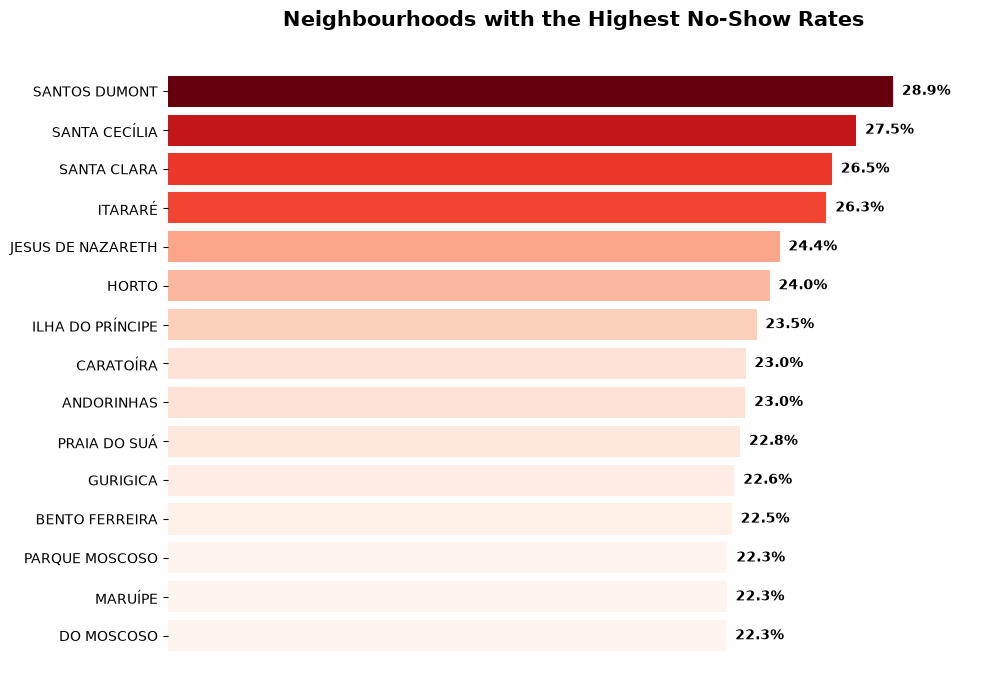

In [22]:
plot_rate = high_rate_neighbourhoods.sort_values(
    'no_show_rate',
    ascending=True
)

norm = Normalize(
    vmin=plot_rate['no_show_rate'].min(),
    vmax=plot_rate['no_show_rate'].max()
)

colors = cm.Reds(
    norm(plot_rate['no_show_rate'])
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_rate['Neighbourhood'],
    plot_rate['no_show_rate'],
    color=colors
)

for bar, value in zip(bars, plot_rate['no_show_rate']):
    ax.text(
        bar.get_width() + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Neighbourhoods with the Highest No-Show Rates',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.xaxis.set_visible(False)
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(
    0,
    plot_rate['no_show_rate'].max() * 1.12
)

plt.tight_layout()
plt.show()


### 6.5 Is Neighbourhood Income Associated with No-Show Rate?

Only neighbourhoods with available IBGE median-income information are included in this analysis.

The Pearson correlation is used as an exploratory measure of linear association. It does not establish causality.


In [23]:
income_analysis = neighbourhood_analysis[
    neighbourhood_analysis['income_median'].notna()
].copy()

income_no_show_corr = (
    income_analysis[
        ['income_median', 'no_show_rate']
    ]
    .corr()
    .loc['income_median', 'no_show_rate']
)

print(
    f"Pearson correlation between median neighbourhood income "
    f"and no-show rate: {income_no_show_corr:.3f}"
)


Pearson correlation between median neighbourhood income and no-show rate: -0.208


### Initial Socioeconomic Finding

The current analysis indicates a **weak negative association** between neighbourhood median income and appointment no-show rate.

The Pearson correlation is approximately **-0.21**, meaning that higher neighbourhood median income tends to be associated with somewhat lower no-show rates in this dataset, although the relationship is not strong.

The income-group analysis also shows that the higher-income group has the lowest observed no-show rate (**18.5%**), while the other three groups are closer to **20–21%**.

This is an **area-level association**. It must not be interpreted as evidence that an individual patient's income causes attendance behaviour.


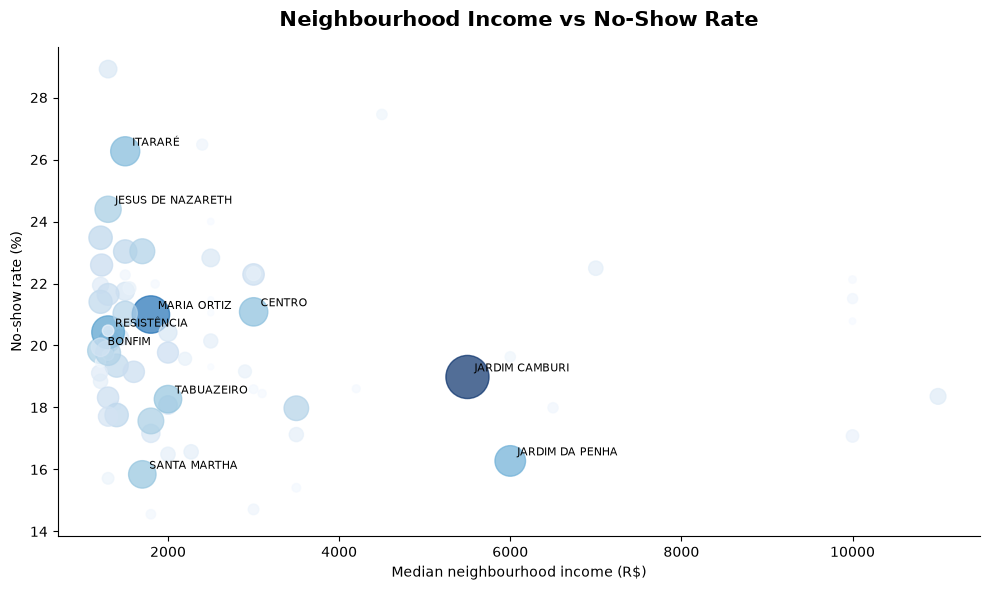

In [24]:
analysis_income = income_analysis[
    income_analysis['appointments'] >= 100
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    analysis_income['income_median'],
    analysis_income['no_show_rate'],
    s=analysis_income['appointments'] / 8,
    c=analysis_income['appointments'],
    cmap='Blues',
    alpha=0.70
)

# Label only the largest-volume neighbourhoods to keep the chart readable.
label_data = analysis_income.nlargest(10, 'appointments')

for _, row in label_data.iterrows():
    ax.annotate(
        row['Neighbourhood'],
        (row['income_median'], row['no_show_rate']),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8
    )

ax.set_xlabel('Median neighbourhood income (R$)')
ax.set_ylabel('No-show rate (%)')
ax.set_title(
    'Neighbourhood Income vs No-Show Rate',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 6.6 No-Show Rate by Neighbourhood Income Quartile

To make the socioeconomic pattern easier to interpret, neighbourhoods are divided into four income groups based on the distribution of median neighbourhood income.

The final no-show rate for each group is calculated using appointment counts, rather than averaging neighbourhood percentages.


In [25]:
income_analysis['income_group'] = pd.qcut(
    income_analysis['income_median'],
    q=4,
    labels=[
        'Lower income',
        'Lower-middle income',
        'Upper-middle income',
        'Higher income'
    ]
)

income_group_analysis = (
    income_analysis.groupby(
        'income_group',
        observed=False
    )
    .agg(
        neighbourhoods=('Neighbourhood', 'count'),
        appointments=('appointments', 'sum'),
        no_shows=('no_shows', 'sum')
    )
    .reset_index()
)

income_group_analysis['no_show_rate'] = (
    income_group_analysis['no_shows']
    / income_group_analysis['appointments']
    * 100
)

income_group_analysis


,income_group,neighbourhoods,appointments,no_shows,no_show_rate
0,Lower income,20,34240,7201,21.030958
1,Lower-middle income,23,43312,8714,20.119136
2,Upper-middle income,15,12289,2569,20.904874
3,Higher income,20,20669,3827,18.515651


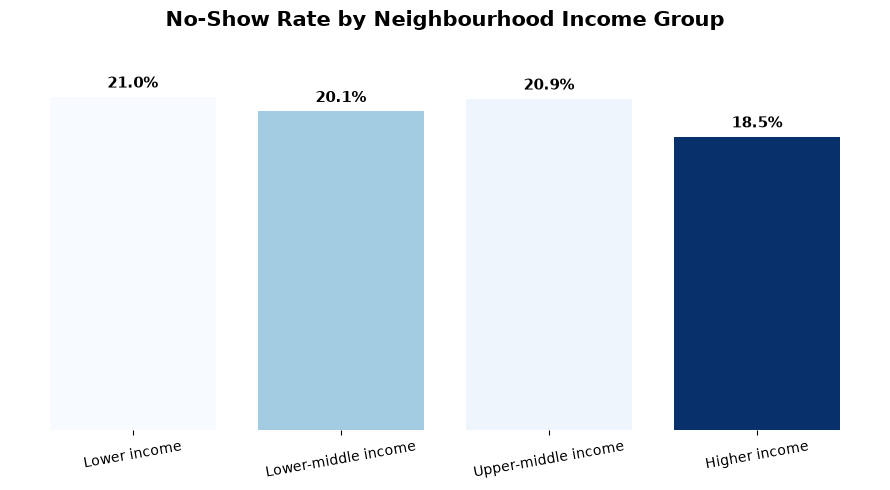

In [26]:
plot_income = income_group_analysis.copy()

norm = Normalize(
    vmin=plot_income['no_show_rate'].min(),
    vmax=plot_income['no_show_rate'].max()
)

colors = cm.Blues_r(
    norm(plot_income['no_show_rate'])
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    plot_income['income_group'].astype(str),
    plot_income['no_show_rate'],
    color=colors
)

for bar, value in zip(bars, plot_income['no_show_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'No-Show Rate by Neighbourhood Income Group',
    fontsize=15,
    fontweight='bold',
    pad=15
)

# Data labels provide the exact percentages, so the numeric Y axis is removed.
ax.yaxis.set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylim(
    0,
    plot_income['no_show_rate'].max() * 1.15
)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### Neighbourhood Analysis — Current Findings

The neighbourhood analysis indicates that **volume and rate answer different operational questions**:

- absolute no-shows identify where the largest number of appointment slots is lost;
- no-show rate identifies where absenteeism is proportionally more intense.

The socioeconomic enrichment suggests that lower-income neighbourhood groups may present higher no-show rates than higher-income groups.

However, neighbourhood income is an **aggregated contextual variable**. It does not represent the income, employment status, education level, transportation access or personal circumstances of each patient.

Therefore, this finding should be treated as an **area-level association**, not as evidence of individual behaviour or causality.


### Preliminary Interpretation Hypotheses

After correcting the scheduling lead-time calculation, an additional pattern is worth investigating:

A large share of no-shows in lower-income neighbourhoods occurs even when the appointment was scheduled **less than 30 days in advance**.

This observation weakens a simple explanation that higher absenteeism in lower-income areas is caused only by longer waiting periods.

Several structural mechanisms could plausibly contribute to the observed pattern, for example:

- limited flexibility to leave work during business hours;
- direct income loss when missing a workday or work shift;
- difficulty attending more than one healthcare appointment within a short period;
- transportation or mobility constraints;
- caregiving responsibilities;
- communication or health-literacy barriers.

The available dataset does **not** contain individual employment status, income, education, transportation, work-schedule flexibility or stated reasons for missing an appointment.

For that reason, these explanations remain **hypotheses for further investigation**. They should not be presented as conclusions from the current data.

The appropriate analytical statement is:

> **Lower-income neighbourhoods show different attendance patterns, but the available data are insufficient to determine why those differences occur.**


# 7. Question 2 — What Is the Impact of Scheduling Lead Time?

The second business question investigates whether the time between scheduling and the appointment is associated with patient attendance.

> **Does a longer waiting period between booking and the appointment correspond to a higher no-show rate?**

The analysis will compare appointment volume and no-show rates across lead-time groups.

Because this is observational data, the results will be interpreted as **associations**, not causal effects.


In [27]:
# Confirm the corrected distribution before grouping
df_clean['waiting_days'].describe()


count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

In [28]:
# Create operational lead-time groups in the main analytical dataset
bins = [-1, 0, 2, 7, 14, 30, 60, float('inf')]

labels = [
    'Same day',
    '1-2 days',
    '3-7 days',
    '8-14 days',
    '15-30 days',
    '31-60 days',
    '61+ days'
]

df_enriched['waiting_group'] = pd.cut(
    df_enriched['waiting_days'],
    bins=bins,
    labels=labels
)

waiting_analysis = (
    df_enriched
    .groupby('waiting_group', observed=False)
    .agg(
        appointments=('AppointmentID', 'count'),
        no_shows=('no_show_flag', 'sum')
    )
    .reset_index()
)

waiting_analysis['no_show_rate'] = (
    waiting_analysis['no_shows']
    / waiting_analysis['appointments']
    * 100
)

waiting_analysis


,waiting_group,appointments,no_shows,no_show_rate
0,Same day,38562,1792,4.647062
1,1-2 days,11938,2715,22.742503
2,3-7 days,20247,5057,24.976540
3,8-14 days,12025,3664,30.469854
4,15-30 days,17371,5661,32.588797
5,31-60 days,8283,2829,34.154292
6,61+ days,2095,596,28.448687


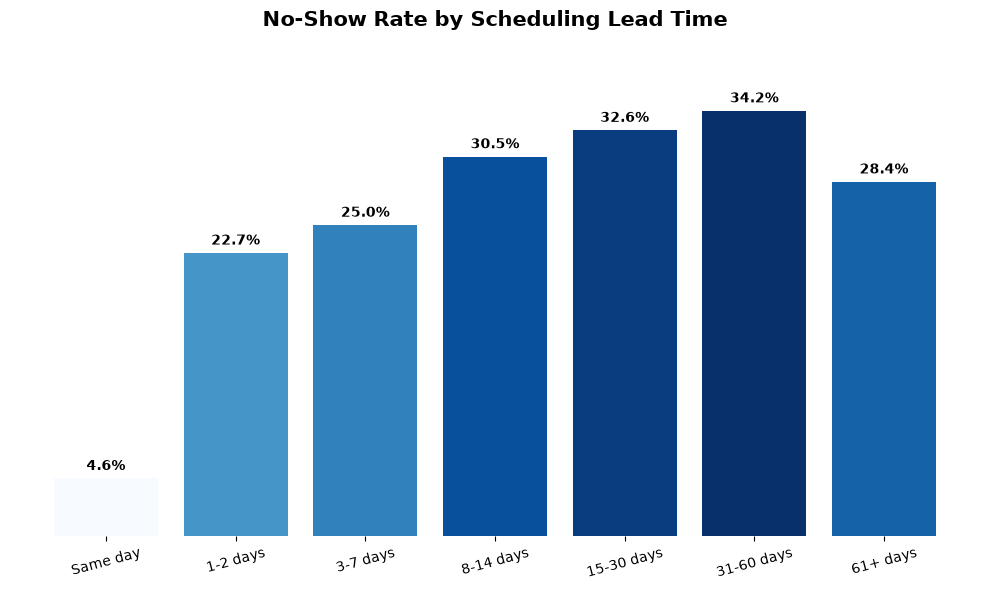

In [29]:
plot_waiting = waiting_analysis.copy()

norm = Normalize(
    vmin=plot_waiting['no_show_rate'].min(),
    vmax=plot_waiting['no_show_rate'].max()
)

colors = cm.Blues(
    norm(plot_waiting['no_show_rate'])
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    plot_waiting['waiting_group'].astype(str),
    plot_waiting['no_show_rate'],
    color=colors
)

for bar, value in zip(bars, plot_waiting['no_show_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'No-Show Rate by Scheduling Lead Time',
    fontsize=15,
    fontweight='bold',
    pad=15
)

# Exact percentages are displayed as labels, so the numeric Y axis is redundant.
ax.yaxis.set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylim(
    0,
    plot_waiting['no_show_rate'].max() * 1.15
)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Scheduling Lead Time — Main Finding

No-show rates increase substantially as the interval between scheduling and
the appointment becomes longer.

Same-day appointments present a no-show rate of only **4.6%**, while
appointments scheduled between **31 and 60 days in advance** reach a no-show
rate of **34.2%**.

The pattern is not perfectly linear, since appointments with a lead time
above 60 days show a lower rate of **28.4%**.

Therefore, the results support the conclusion that longer scheduling lead
times are strongly associated with higher absenteeism, particularly up to
the 31–60 day range.

However, this analysis is observational and does not establish that waiting
time itself causes patients to miss appointments. Other unobserved factors
may influence both scheduling lead time and attendance behaviour.

### Additional Interpretation Hypothesis

The increase in no-show rates as scheduling lead time becomes longer may also
be influenced by clinical factors that are not available in the dataset.

Possible explanations include:

- patients with more serious or persistent health conditions may remain more
  motivated to attend even after a long waiting period;
- patients with less severe conditions may experience symptom improvement
  before the appointment date;
- some patients may seek alternative care or resolve the issue through another
  healthcare provider while waiting;
- the perceived need for the appointment may decrease over time.

The dataset does not contain diagnosis, clinical severity, treatment outcome,
reason for appointment, or information about alternative care.

Therefore, these explanations remain **plausible hypotheses only** and cannot
be validated with the available data.

# 8. Question 3 — Which Days Present Higher No-Show Risk?

This section evaluates whether no-show behaviour varies meaningfully across weekdays and whether the pattern changes when observed recurrence, neighbourhood and socioeconomic context are considered.

The analysis is organized into three levels:

1. **Overall weekday effect**
2. **First vs repeat observed appointments**
3. **Neighbourhood and income context**

The dataset does not contain an official first-visit/follow-up field. Therefore, recurrence is treated only as an analytical proxy.


## 8.1 Feature Preparation

The variables required for the weekday analysis are created once in the enriched analytical dataset.

`observed_visit_type` is based on the sequence in which each `PatientId` appears in the available data:

- **First observed appointment** — first appointment observed for that patient;
- **Repeat observed appointment** — any later appointment observed for the same patient.

This does **not** confirm that a repeated appointment is a clinical follow-up. It may represent another specialty, another health condition or an unrelated appointment.


In [30]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Appointment weekday
df_enriched['appointment_weekday'] = (
    df_enriched['AppointmentDay']
    .dt.day_name()
)

df_enriched['appointment_weekday'] = pd.Categorical(
    df_enriched['appointment_weekday'],
    categories=weekday_order,
    ordered=True
)

# Neighbourhood income quartiles
df_enriched['income_group'] = pd.qcut(
    df_enriched['income_median'],
    q=4,
    labels=[
        'Lower income',
        'Lower-middle income',
        'Upper-middle income',
        'Higher income'
    ]
)

# Observed appointment sequence
df_enriched = df_enriched.sort_values(
    ['PatientId', 'AppointmentDay', 'ScheduledDay', 'AppointmentID']
)

df_enriched['observed_sequence'] = (
    df_enriched.groupby('PatientId')
    .cumcount() + 1
)

df_enriched['observed_visit_type'] = np.where(
    df_enriched['observed_sequence'].eq(1),
    'First observed appointment',
    'Repeat observed appointment'
)


### Reusable No-Show Summary

A single helper function is used throughout this section to avoid repeating the same aggregation logic for every analytical cut.


In [31]:
def summarize_no_show(data, group_cols):
    summary = (
        data
        .groupby(group_cols, observed=False)
        .agg(
            appointments=('AppointmentID', 'count'),
            no_shows=('no_show_flag', 'sum')
        )
        .reset_index()
    )

    summary['no_show_rate'] = (
        summary['no_shows']
        / summary['appointments']
        * 100
    )

    return summary


## 8.2 Overall Weekday Effect

The first view evaluates whether weekday alone is associated with materially different no-show rates.


In [32]:
weekday_analysis = summarize_no_show(
    df_enriched,
    ['appointment_weekday']
)

weekday_analysis = weekday_analysis[
    weekday_analysis['appointments'] > 0
].copy()

weekday_analysis


,appointment_weekday,appointments,no_shows,no_show_rate
0,Monday,22713,4689,20.644565
1,Tuesday,25638,5150,20.087370
2,Wednesday,25866,5092,19.686074
3,Thursday,17246,3337,19.349414
4,Friday,19019,4037,21.226142
5,Saturday,39,9,23.076923


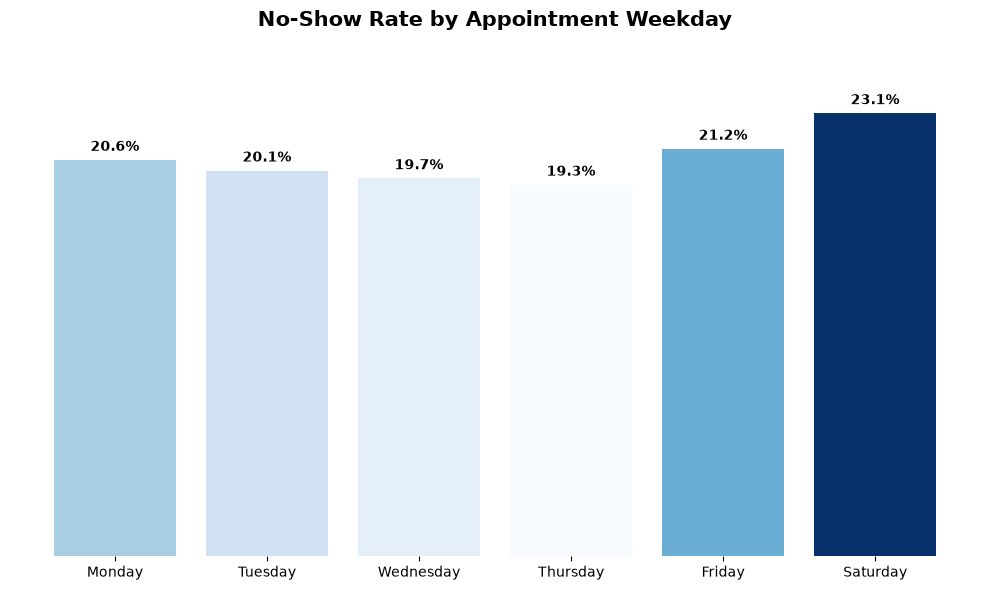

In [33]:
plot_weekday = weekday_analysis.copy()

norm = Normalize(
    vmin=plot_weekday['no_show_rate'].min(),
    vmax=plot_weekday['no_show_rate'].max()
)

colors = cm.Blues(
    norm(plot_weekday['no_show_rate'])
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    plot_weekday['appointment_weekday'].astype(str),
    plot_weekday['no_show_rate'],
    color=colors
)

for bar, value in zip(bars, plot_weekday['no_show_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'No-Show Rate by Appointment Weekday',
    fontsize=15,
    fontweight='bold',
    pad=15
)

# Exact values are already displayed as data labels.
ax.yaxis.set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylim(
    0,
    plot_weekday['no_show_rate'].max() * 1.15
)

plt.tight_layout()
plt.show()


### Main Finding

No-show rates are relatively stable across weekdays with substantial appointment volume.

From Monday to Friday, rates range from approximately **19.3% to 21.2%**. Friday has the highest observed weekday rate and Thursday the lowest, but the difference is only about **1.9 percentage points**.

Saturday should not be interpreted as the highest-risk day because it contains only **39 appointments**, making its rate unstable.

Overall, weekday appears to have a much smaller association with no-show behaviour than scheduling lead time.


## 8.3 First vs Repeat Observed Appointments

The recurrence proxy is used to test whether weekday patterns differ between the first appointment observed for a patient and later appointments observed for the same patient.


In [34]:
visit_weekday_analysis = summarize_no_show(
    df_enriched,
    ['observed_visit_type', 'appointment_weekday']
)

visit_weekday_analysis = visit_weekday_analysis[
    visit_weekday_analysis['appointments'] > 0
].copy()

visit_weekday_analysis


,observed_visit_type,appointment_weekday,appointments,no_shows,no_show_rate
0,First observed appointment,Monday,13440,2732,20.327381
1,First observed appointment,Tuesday,14152,2669,18.859525
2,First observed appointment,Wednesday,13559,2589,19.094328
3,First observed appointment,Thursday,9905,1857,18.748107
4,First observed appointment,Friday,11215,2311,20.606331
5,First observed appointment,Saturday,27,6,22.222222
7,Repeat observed appointment,Monday,9273,1957,21.104281
8,Repeat observed appointment,Tuesday,11486,2481,21.600209
9,Repeat observed appointment,Wednesday,12307,2503,20.338019
10,Repeat observed appointment,Thursday,7341,1480,20.160741


In [35]:
visit_type_summary = summarize_no_show(
    df_enriched,
    ['observed_visit_type']
)

visit_type_summary


,observed_visit_type,appointments,no_shows,no_show_rate
0,First observed appointment,62298,12164,19.525506
1,Repeat observed appointment,48223,10150,21.048048


### Interpretation

Repeat observed appointments show a slightly higher no-show rate than first observed appointments in the available dataset.

The difference is useful as an exploratory signal, but it should not be interpreted as evidence that clinical follow-up appointments are inherently more likely to be missed because the dataset does not identify appointment type or clinical purpose.


## 8.4 Neighbourhood and Income Context

The final drill-down combines repeat observed appointments with neighbourhood, income group and weekday.

This produces one reusable analytical table from which we can identify:

- neighbourhoods with high repeat-observed no-show rates on specific weekdays;
- the worst weekday within each neighbourhood, subject to a minimum volume;
- whether the weekday pattern differs across neighbourhood income groups.

A minimum threshold of **100 appointments per neighbourhood-weekday combination** is used to reduce instability from very small denominators.


In [36]:
repeat_context_analysis = summarize_no_show(
    df_enriched[
        (df_enriched['observed_visit_type']
         == 'Repeat observed appointment') &
        (df_enriched['income_median'].notna())
    ],
    [
        'Neighbourhood',
        'income_group',
        'appointment_weekday'
    ]
)

repeat_context_valid = repeat_context_analysis[
    repeat_context_analysis['appointments'] >= 100
].copy()

repeat_context_valid.head()


,Neighbourhood,income_group,appointment_weekday,appointments,no_shows,no_show_rate
7,ANDORINHAS,Lower-middle income,Monday,189,55,29.100529
8,ANDORINHAS,Lower-middle income,Tuesday,283,80,28.268551
9,ANDORINHAS,Lower-middle income,Wednesday,321,81,25.233645
10,ANDORINHAS,Lower-middle income,Thursday,163,42,25.766871
11,ANDORINHAS,Lower-middle income,Friday,173,35,20.231214


In [37]:
# Worst weekday by neighbourhood among valid repeat-observed combinations
worst_repeat_day_by_neighbourhood = (
    repeat_context_valid
    .loc[
        repeat_context_valid
        .groupby('Neighbourhood')['no_show_rate']
        .idxmax()
    ]
    .sort_values(
        ['no_show_rate', 'appointments'],
        ascending=[False, False]
    )
)

worst_repeat_day_by_neighbourhood[
    [
        'Neighbourhood',
        'income_group',
        'appointment_weekday',
        'appointments',
        'no_shows',
        'no_show_rate'
    ]
].head(20)


,Neighbourhood,income_group,appointment_weekday,appointments,no_shows,no_show_rate
900,ILHA DO PRÍNCIPE,Lower income,Friday,195,66,33.846154
2048,SÃO JOSÉ,Lower income,Friday,184,59,32.065217
1198,MARUÍPE,Higher income,Tuesday,200,63,31.500000
1877,SANTOS DUMONT,Lower income,Tuesday,162,50,30.864198
1824,SANTO ANDRÉ,Lower income,Friday,215,66,30.697674
959,ITARARÉ,Lower-middle income,Monday,257,77,29.961089
2079,SÃO PEDRO,Lower-middle income,Monday,226,67,29.646018
7,ANDORINHAS,Lower-middle income,Monday,189,55,29.100529
728,GURIGICA,Lower income,Monday,155,45,29.032258
1499,PRAIA DO SUÁ,Upper-middle income,Tuesday,138,40,28.985507


In [38]:
# Income-group weekday pattern using all appointments with available income
income_weekday_analysis = summarize_no_show(
    df_enriched[
        df_enriched['income_median'].notna()
    ],
    ['income_group', 'appointment_weekday']
)

income_weekday_analysis = income_weekday_analysis[
    income_weekday_analysis['appointments'] >= 100
].copy()

income_weekday_pivot = (
    income_weekday_analysis
    .pivot(
        index='appointment_weekday',
        columns='income_group',
        values='no_show_rate'
    )
)

income_weekday_pivot


income_group,Lower income,Lower-middle income,Upper-middle income,Higher income
appointment_weekday,,,,
Monday,21.886121,21.329797,20.178463,18.968213
Tuesday,20.355813,20.655525,19.261942,19.987547
Wednesday,20.352851,20.399476,19.745565,18.127459
Thursday,19.007928,20.523483,18.556701,19.351808
Friday,23.905664,21.550352,19.445087,19.343843


In [39]:
# Highest no-show weekday within each income group
worst_day_by_income = (
    income_weekday_analysis
    .loc[
        income_weekday_analysis
        .groupby('income_group', observed=False)['no_show_rate']
        .idxmax()
    ]
    .sort_values('no_show_rate', ascending=False)
)

worst_day_by_income[
    [
        'income_group',
        'appointment_weekday',
        'appointments',
        'no_shows',
        'no_show_rate'
    ]
]


,income_group,appointment_weekday,appointments,no_shows,no_show_rate
4,Lower income,Friday,5597,1338,23.905664
11,Lower-middle income,Friday,4399,948,21.550352
14,Upper-middle income,Monday,4931,995,20.178463
22,Higher income,Tuesday,6424,1284,19.987547


### Question 3 — Interpretation

The weekday analysis suggests that **day of week is a secondary operational factor rather than a dominant driver of absenteeism**.

The overall Monday-to-Friday variation is small compared with the much larger differences observed across scheduling lead-time groups.

The recurrence and contextual drill-downs are still useful operationally because they can identify local combinations of:

> **repeat observed appointments + neighbourhood + income context + weekday**

with elevated no-show rates and sufficient appointment volume.

These results may support more localized staffing, scheduling or reminder strategies. However:

- `observed_visit_type` is only a recurrence proxy;
- neighbourhood income is contextual rather than individual;
- weekday differences are associations, not causal effects.

The analysis therefore supports prioritization and further investigation rather than deterministic scheduling rules.


# 9. Question 4 — Is SMS Communication Associated with Better Attendance?

This analysis investigates whether receiving an SMS reminder is associated
with a lower appointment no-show rate.

The first step compares attendance outcomes between patients who received an
SMS and those who did not.

Because SMS assignment may be related to other operational factors, especially
scheduling lead time, the analysis also evaluates SMS performance within
different waiting-time groups.

The results should be interpreted as associations rather than causal effects.

In [40]:
sms_analysis = summarize_no_show(
    df_enriched,
    ['SMS_received']
)

sms_analysis['SMS_received'] = sms_analysis['SMS_received'].map({
    0: 'No SMS',
    1: 'SMS received'
})

sms_analysis

,SMS_received,appointments,no_shows,no_show_rate
0,No SMS,75039,12530,16.697984
1,SMS received,35482,9784,27.574545


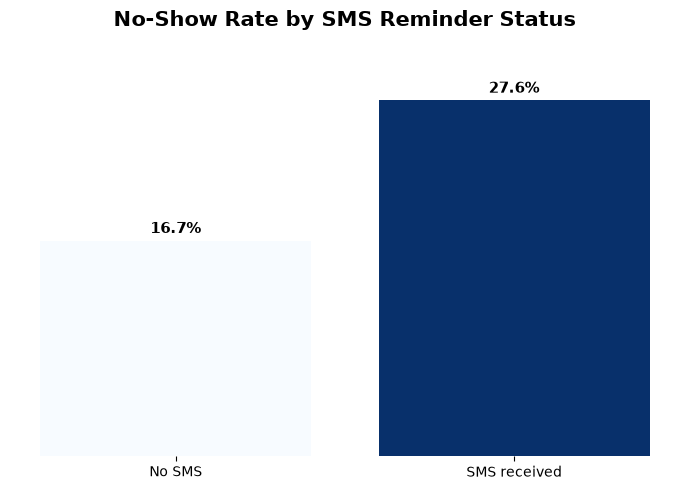

In [41]:
plot_sms = sms_analysis.copy()

norm = Normalize(
    vmin=plot_sms['no_show_rate'].min(),
    vmax=plot_sms['no_show_rate'].max()
)

colors = cm.Blues(
    norm(plot_sms['no_show_rate'])
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    plot_sms['SMS_received'],
    plot_sms['no_show_rate'],
    color=colors
)

for bar, value in zip(bars, plot_sms['no_show_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'No-Show Rate by SMS Reminder Status',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.yaxis.set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylim(
    0,
    plot_sms['no_show_rate'].max() * 1.15
)

plt.tight_layout()
plt.show()

In [42]:
# Confirm that the lead-time grouping created in Question 2 is available
df_enriched[
    ['waiting_days', 'waiting_group']
].head()


,waiting_days,waiting_group
100511,3,3-7 days
105424,0,Same day
3950,0,Same day
73298,3,3-7 days
73223,7,3-7 days


In [43]:
df_enriched['waiting_group'].value_counts(sort=False)


waiting_group
Same day      38562
1-2 days      11938
3-7 days      20247
8-14 days     12025
15-30 days    17371
31-60 days     8283
61+ days       2095
Name: count, dtype: int64

In [44]:
sms_waiting_analysis = summarize_no_show(
    df_enriched,
    ['waiting_group', 'SMS_received']
)

sms_waiting_analysis['SMS_received'] = (
    sms_waiting_analysis['SMS_received']
    .map({
        0: 'No SMS',
        1: 'SMS received'
    })
)

sms_waiting_analysis

,waiting_group,SMS_received,appointments,no_shows,no_show_rate
0,Same day,No SMS,38562,1792,4.647062
1,Same day,SMS received,0,0,NaN
2,1-2 days,No SMS,11938,2715,22.742503
3,1-2 days,SMS received,0,0,NaN
4,3-7 days,No SMS,8699,2313,26.589263
5,3-7 days,SMS received,11548,2744,23.761690
6,8-14 days,No SMS,5021,1695,33.758215
7,8-14 days,SMS received,7004,1969,28.112507
8,15-30 days,No SMS,6851,2526,36.870530
9,15-30 days,SMS received,10520,3135,29.800380


In [45]:
sms_waiting_pivot = (
    sms_waiting_analysis
    .pivot(
        index='waiting_group',
        columns='SMS_received',
        values='no_show_rate'
    )
)

sms_waiting_pivot

SMS_received,No SMS,SMS received
waiting_group,,
Same day,4.647062,NaN
1-2 days,22.742503,NaN
3-7 days,26.589263,23.761690
8-14 days,33.758215,28.112507
15-30 days,36.870530,29.800380
31-60 days,38.368486,31.468670
61+ days,33.870968,25.462620


In [46]:
sms_waiting_profile = (
    df_enriched
    .groupby('SMS_received')
    .agg(
        appointments=('AppointmentID', 'count'),
        mean_waiting_days=('waiting_days', 'mean'),
        median_waiting_days=('waiting_days', 'median')
    )
    .reset_index()
)

sms_waiting_profile

,SMS_received,appointments,mean_waiting_days,median_waiting_days
0,0,75039,6.007983,0.0
1,1,35482,19.016713,14.0


### SMS Reminder — Main Finding

The crude comparison suggests that appointments with an SMS reminder have a
higher no-show rate than appointments without SMS:

- No SMS: **16.7%**
- SMS received: **27.6%**

However, this comparison is strongly affected by scheduling lead time.

Appointments receiving SMS have a substantially longer waiting period:

- No SMS: mean waiting time **6.0 days**, median **0 days**
- SMS received: mean waiting time **19.0 days**, median **14 days**

This indicates that SMS reminders were not distributed uniformly across all
appointments.

When appointments are compared within similar scheduling lead-time groups,
SMS recipients consistently show lower no-show rates:

- 3–7 days: 26.6% without SMS vs 23.8% with SMS
- 8–14 days: 33.8% vs 28.1%
- 15–30 days: 36.9% vs 29.8%
- 31–60 days: 38.4% vs 31.5%
- 61+ days: 33.9% vs 25.5%

Therefore, the higher overall no-show rate among SMS recipients appears to be
largely explained by the fact that SMS was concentrated among appointments
with longer scheduling lead times.

Within comparable waiting-time groups, receiving an SMS is associated with
lower absenteeism.

# 10. Question 5 — How Many Appointment Slots Could Potentially Be Recovered?

This analysis estimates how many missed appointment slots could potentially be recovered under different hypothetical reductions in the no-show rate.

The objective is to translate absenteeism into an operational capacity perspective.

These values are **scenario-based estimates**, not forecasts. They do not assume that every missed appointment can actually be recovered.

In [47]:
total_appointments = len(df_enriched)
total_no_shows = df_enriched['no_show_flag'].sum()
overall_no_show_rate = total_no_shows / total_appointments * 100

print(f"Total appointments: {total_appointments:,}")
print(f"Total no-shows: {total_no_shows:,}")
print(f"Overall no-show rate: {overall_no_show_rate:.1f}%")

Total appointments: 110,521
Total no-shows: 22,314
Overall no-show rate: 20.2%


In [48]:
recovery_scenarios = pd.DataFrame({
    'reduction_target': [0.10, 0.20, 0.30]
})

recovery_scenarios['potentially_recovered_slots'] = (
    total_no_shows
    * recovery_scenarios['reduction_target']
).round().astype(int)

recovery_scenarios['reduction_target'] = (
    recovery_scenarios['reduction_target'] * 100
)

recovery_scenarios

,reduction_target,potentially_recovered_slots
0,10.0,2231
1,20.0,4463
2,30.0,6694


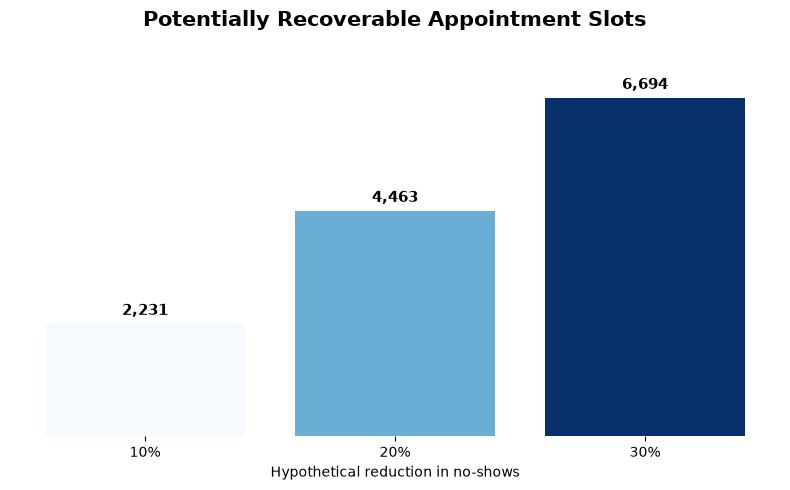

In [49]:
plot_recovery = recovery_scenarios.copy()

norm = Normalize(
    vmin=plot_recovery['potentially_recovered_slots'].min(),
    vmax=plot_recovery['potentially_recovered_slots'].max()
)

colors = cm.Blues(
    norm(plot_recovery['potentially_recovered_slots'])
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_recovery['reduction_target'].astype(int).astype(str) + '%',
    plot_recovery['potentially_recovered_slots'],
    color=colors
)

for bar, value in zip(
    bars,
    plot_recovery['potentially_recovered_slots']
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{value:,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'Potentially Recoverable Appointment Slots',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.yaxis.set_visible(False)
ax.set_xlabel('Hypothetical reduction in no-shows')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylim(
    0,
    plot_recovery['potentially_recovered_slots'].max() * 1.15
)

plt.tight_layout()
plt.show()

### Operational Interpretation

Even a modest reduction in appointment absenteeism could represent a meaningful increase in available healthcare capacity.

For example, a hypothetical 20% reduction in no-shows would correspond to several thousand appointment slots potentially becoming available.

This does not mean that all recovered slots would automatically be reassigned to other patients. Actual recovery would depend on operational factors such as cancellation timing, wait-list management, staffing capacity and appointment replacement processes.

The metric should therefore be interpreted as **potential recoverable capacity** rather than guaranteed additional care delivery.

# 11. Question 6 — Which Groups Could Receive Prioritized Communication?

The final business question identifies appointment groups that could be
prioritized for reminder or communication strategies.

Rather than creating an arbitrary risk score, prioritization is based on two
transparent criteria:

1. the group presents a no-show rate above the overall average;
2. the group represents a meaningful volume of missed appointments.

Scheduling lead time is treated as the primary segmentation variable because
it showed the strongest association with absenteeism in the previous analyses.

Observed recurrence and neighbourhood income are included as contextual
dimensions that may help refine communication strategies.

In [50]:
overall_no_show_rate = (
    df_enriched['no_show_flag'].mean() * 100
)

print(
    f'Overall no-show rate: '
    f'{overall_no_show_rate:.1f}%'
)

Overall no-show rate: 20.2%


In [51]:
communication_segments = summarize_no_show(
    df_enriched[
        df_enriched['income_median'].notna()
    ],
    [
        'waiting_group',
        'observed_visit_type',
        'income_group'
    ]
)

communication_segments = communication_segments[
    communication_segments['appointments'] > 0
].copy()

communication_segments

,waiting_group,observed_visit_type,income_group,appointments,no_shows,no_show_rate
0,Same day,First observed appointment,Lower income,6537,247,3.778492
1,Same day,First observed appointment,Lower-middle income,5571,202,3.625920
2,Same day,First observed appointment,Upper-middle income,4902,139,2.835577
3,Same day,First observed appointment,Higher income,4709,160,3.397749
4,Same day,Repeat observed appointment,Lower income,5308,351,6.612660
5,Same day,Repeat observed appointment,Lower-middle income,3974,269,6.768998
6,Same day,Repeat observed appointment,Upper-middle income,3741,232,6.201550
7,Same day,Repeat observed appointment,Higher income,3816,192,5.031447
8,1-2 days,First observed appointment,Lower income,1572,377,23.982188
9,1-2 days,First observed appointment,Lower-middle income,1641,402,24.497258


In [52]:
priority_segments = (
    communication_segments[
        communication_segments['no_show_rate']
        > overall_no_show_rate
    ]
    .sort_values(
        ['no_shows', 'no_show_rate'],
        ascending=[False, False]
    )
)

priority_segments[
    [
        'waiting_group',
        'observed_visit_type',
        'income_group',
        'appointments',
        'no_shows',
        'no_show_rate'
    ]
].head(15)

,waiting_group,observed_visit_type,income_group,appointments,no_shows,no_show_rate
35,15-30 days,First observed appointment,Higher income,3532,901,25.509626
16,3-7 days,First observed appointment,Lower income,3708,898,24.217907
33,15-30 days,First observed appointment,Lower-middle income,2321,889,38.302456
20,3-7 days,Repeat observed appointment,Lower income,3320,889,26.777108
32,15-30 days,First observed appointment,Lower income,2200,799,36.318182
34,15-30 days,First observed appointment,Upper-middle income,2728,784,28.739003
28,8-14 days,Repeat observed appointment,Lower income,2012,725,36.033797
17,3-7 days,First observed appointment,Lower-middle income,2575,682,26.485437
36,15-30 days,Repeat observed appointment,Lower income,1691,655,38.734477
24,8-14 days,First observed appointment,Lower income,2130,648,30.422535


In [53]:
communication_opportunity = summarize_no_show(
    df_enriched[
        (df_enriched['SMS_received'] == 0) &
        (df_enriched['income_median'].notna())
    ],
    [
        'waiting_group',
        'observed_visit_type',
        'income_group'
    ]
)

communication_opportunity = (
    communication_opportunity[
        communication_opportunity['no_show_rate']
        > overall_no_show_rate
    ]
    .sort_values(
        ['no_shows', 'no_show_rate'],
        ascending=[False, False]
    )
)

communication_opportunity[
    [
        'waiting_group',
        'observed_visit_type',
        'income_group',
        'appointments',
        'no_shows',
        'no_show_rate'
    ]
].head(15)

,waiting_group,observed_visit_type,income_group,appointments,no_shows,no_show_rate
20,3-7 days,Repeat observed appointment,Lower income,1504,415,27.593085
9,1-2 days,First observed appointment,Lower-middle income,1641,402,24.497258
33,15-30 days,First observed appointment,Lower-middle income,983,388,39.471007
35,15-30 days,First observed appointment,Higher income,1270,385,30.314961
16,3-7 days,First observed appointment,Lower income,1458,378,25.925926
28,8-14 days,Repeat observed appointment,Lower income,946,377,39.852008
8,1-2 days,First observed appointment,Lower income,1572,377,23.982188
11,1-2 days,First observed appointment,Higher income,1567,367,23.420549
12,1-2 days,Repeat observed appointment,Lower income,1700,364,21.411765
15,1-2 days,Repeat observed appointment,Higher income,1614,353,21.871128


In [54]:
top_priority = (
    communication_opportunity
    .head(10)
    .copy()
)

top_priority['segment'] = (
    top_priority['waiting_group'].astype(str)
    + ' | '
    + top_priority['observed_visit_type']
    + ' | '
    + top_priority['income_group'].astype(str)
)

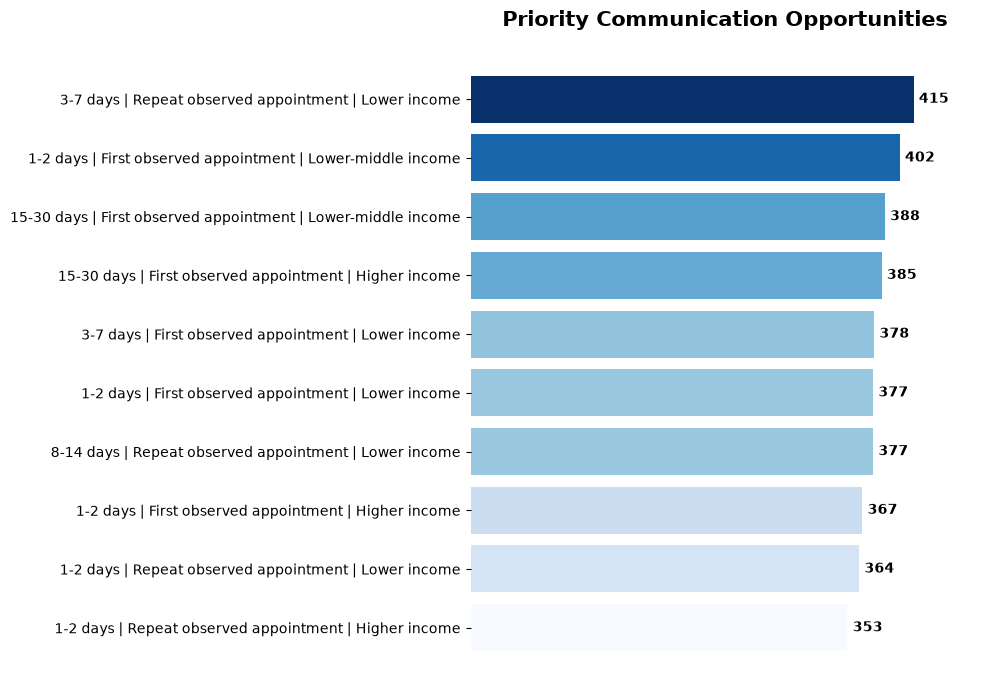

In [55]:
plot_priority = (
    top_priority
    .sort_values('no_shows')
)

norm = Normalize(
    vmin=plot_priority['no_shows'].min(),
    vmax=plot_priority['no_shows'].max()
)

colors = cm.Blues(
    norm(plot_priority['no_shows'])
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_priority['segment'],
    plot_priority['no_shows'],
    color=colors
)

for bar, value in zip(
    bars,
    plot_priority['no_shows']
):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Priority Communication Opportunities',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.xaxis.set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(
    0,
    plot_priority['no_shows'].max() * 1.15
)

plt.tight_layout()
plt.show()

### Communication Prioritization — Interpretation

The results suggest that communication strategies should not be applied
uniformly across all appointments.

Scheduling lead time remains the clearest operational signal identified in
the analysis. Appointments scheduled further in advance consistently present
higher absenteeism rates.

Communication could therefore be prioritized first toward appointments with
longer scheduling lead times, while observed recurrence and neighbourhood
income context can be used to refine targeting.

A particularly relevant operational opportunity is represented by
higher-risk segments that currently do not receive SMS reminders.

Previous analysis showed that, within comparable waiting-time groups, SMS
recipients consistently presented lower no-show rates. This makes targeted
communication among long-wait appointments a reasonable intervention to test.

However, these findings do not establish causality. The appropriate next step
would be to evaluate targeted reminder strategies through a controlled pilot
and measure whether absenteeism actually decreases.

# 12. Executive Summary

This project analyzed **110,521 valid appointment records** to identify operational patterns associated with missed appointments in a public healthcare setting.

The main findings are:

- **Scheduling lead time is the strongest operational signal identified.** Same-day appointments show a no-show rate of approximately **4.6%**, compared with **34.2%** for appointments scheduled 31–60 days in advance.
- **Weekday has a comparatively small effect.** Monday-to-Friday no-show rates remain within a narrow range of approximately **19.3% to 21.2%**.
- **Neighbourhood income provides useful contextual information, but the association is weak.** The Pearson correlation between neighbourhood median income and no-show rate is approximately **-0.21**.
- **Repeat observed appointments show slightly higher absenteeism** than first observed appointments (**21.0% vs 19.5%**), although this variable is only a recurrence proxy and not a confirmed clinical follow-up indicator.
- **The crude SMS comparison is misleading without considering lead time.** SMS recipients have a higher overall no-show rate because they are concentrated among appointments with longer waiting periods. Within comparable waiting-time groups, SMS recipients consistently show lower no-show rates.
- The dataset contains **22,314 no-shows**, representing an overall no-show rate of approximately **20.2%**.
- A hypothetical reduction of **20% in no-shows** would correspond to approximately **4,463 potentially recoverable appointment slots**.

Overall, the analysis suggests that communication and scheduling interventions should focus primarily on appointments booked further in advance, while neighbourhood, observed recurrence and income context can be used to refine operational targeting.


# 13. Recommendations

Based on the observed patterns, the following actions are reasonable candidates for operational testing:

1. **Prioritize reminders for longer lead-time appointments.** These appointments consistently present higher absenteeism and represent the clearest intervention opportunity identified in the data.
2. **Test expanded SMS coverage within comparable lead-time groups.** The current observational results suggest lower no-show rates among SMS recipients once scheduling lead time is taken into account.
3. **Use targeted rather than uniform communication.** Neighbourhood, observed recurrence and income context can help identify groups where missed appointments combine high rates with meaningful operational volume.
4. **Consider short-notice replacement mechanisms.** Wait-list or cancellation-replacement processes could help convert some missed or cancelled capacity into completed appointments.
5. **Evaluate interventions through a controlled pilot.** Reminder strategies should be tested prospectively before being scaled, using clear outcome measures such as no-show rate, recovered slots and successful replacements.


# 14. Analytical Limitations

Several limitations should be considered when interpreting the results:

- The analysis is **observational** and does not establish causal relationships.
- Neighbourhood income is an **area-level socioeconomic measure**, not individual patient income.
- The dataset does not include employment status, education, transportation access, caregiving responsibilities or stated reasons for missing appointments.
- `observed_visit_type` is a **recurrence proxy** based on repeated `PatientId` records and does not identify confirmed clinical follow-up appointments.
- The operational rule governing **SMS eligibility or assignment is unknown**.
- The dataset does not contain diagnosis, clinical severity, specialty, appointment purpose or treatment outcome.
- Potentially recoverable appointment slots are **scenario estimates**, not guaranteed additional care delivery.

These limitations do not invalidate the operational patterns identified, but they define the boundary between evidence supported by the dataset and hypotheses requiring additional data or prospective testing.


# 15. Export Analytical Dataset for SQL Staging

The enriched analytical dataset is exported to CSV to populate the SQL staging layer.

This staging file preserves the cleaned and derived variables used in the analysis
before the data is transformed into the dimensional model.

In [61]:
staging_export = df_enriched[
    [
        'PatientId',
        'AppointmentID',
        'Gender',
        'ScheduledDay',
        'AppointmentDay',
        'Age',
        'Neighbourhood',
        'Scholarship',
        'Hipertension',
        'Diabetes',
        'Alcoholism',
        'Handcap',
        'SMS_received',
        'no_show_flag',
        'waiting_days',
        'waiting_group',
        'observed_visit_type',
        'income_mean',
        'income_median',
        'responsible_persons',
        'residents',
        'income_group'
    ]
].copy()

In [62]:
staging_export = staging_export.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'no_show_flag': 'NoShowFlag',
    'waiting_days': 'WaitingDays',
    'waiting_group': 'WaitingGroup',
    'observed_visit_type': 'ObservedVisitType',
    'income_mean': 'IncomeMean',
    'income_median': 'IncomeMedian',
    'responsible_persons': 'ResponsiblePersons',
    'residents': 'Residents',
    'income_group': 'IncomeGroup'
})

In [63]:
staging_export.columns.tolist()

['PatientId',
 'AppointmentID',
 'Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Neighbourhood',
 'Scholarship',
 'Hypertension',
 'Diabetes',
 'Alcoholism',
 'Handicap',
 'SMS_received',
 'NoShowFlag',
 'WaitingDays',
 'WaitingGroup',
 'ObservedVisitType',
 'IncomeMean',
 'IncomeMedian',
 'ResponsiblePersons',
 'Residents',
 'IncomeGroup']

In [64]:
print('Rows:', len(staging_export))
print('Columns:', staging_export.shape[1])

staging_export.isna().sum()

Rows: 110521
Columns: 22


PatientId              0
AppointmentID          0
Gender                 0
ScheduledDay           0
AppointmentDay         0
Age                    0
Neighbourhood          0
Scholarship            0
Hypertension           0
Diabetes               0
Alcoholism             0
Handicap               0
SMS_received           0
NoShowFlag             0
WaitingDays            0
WaitingGroup           0
ObservedVisitType      0
IncomeMean            11
IncomeMedian          11
ResponsiblePersons    11
Residents             11
IncomeGroup           11
dtype: int64

In [65]:
staging_export['PatientId'] = (
    staging_export['PatientId']
    .astype(str)
)

In [66]:
for col in ['IncomeMean', 'IncomeMedian']:
    staging_export[col] = (
        staging_export[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    staging_export[col] = pd.to_numeric(
        staging_export[col],
        errors='coerce'
    )

In [67]:
staging_export[
    ['PatientId', 'IncomeMean', 'IncomeMedian']
].head()

,PatientId,IncomeMean,IncomeMedian
100511,39217.84439,4991.21,2500.0
105424,43741.75652,2377.33,1800.0
3950,93779.52927,4390.34,3001.0
73298,141724.16655,1942.61,1300.0
73223,537615.28476,1942.61,1300.0


In [68]:
staging_export.to_csv(
    'stg_appointments.csv',
    index=False,
    encoding='utf-8-sig'
)

print('CSV created successfully.')

CSV created successfully.
